In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

In [2]:
landslides = pd.read_csv('../../Data Cleaning/archive (1)/catalog.csv')

np.random.seed(10)

landslides.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


In [3]:
landslides['date'].dtype

dtype('O')

In [4]:
landslides["parsed_date"] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

landslides['parsed_date'].dtype

dtype('<M8[ns]')

In [5]:
landslides['parsed_date'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: parsed_date, dtype: datetime64[ns]

In [6]:
# get the day of the month from new parsed_date column
day_of_month = landslides['parsed_date'].dt.day
day_of_month.head()

0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: parsed_date, dtype: float64

#### Plot the day of the month to check the date parsing

One of the biggest dangers in parsing dates is mixing up the months and days. The `to_datetime()` function does have very helpful error messages, but it doesn't hurt to double-check that the days of the month we've extracted make sense. 

To do this, let's plot a histogram of the days of the month. We expect it to have values between 1 and 31 and, since there's no reason to suppose the landslides are more common on some days of the month than others, a relatively even distribution. (With a dip on 31 because not all months have 31 days.) Let's see if that's the case:

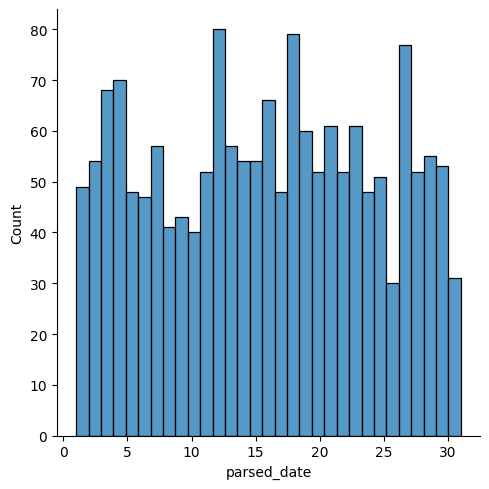

In [7]:
day_of_month_landslides = day_of_month.dropna()

sns.displot(day_of_month_landslides, kde=False, bins=31)